# Librairies 📚

In [5]:
# =========================
# Standard library
# =========================
import os
import sys
from pathlib import Path
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

# =========================
# Local imports (src/)
# =========================
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers as of
import src.distrib_pred_type as dpt
import src.analyse_bivariee as ab

/home/maxime/projects/technova-attrition


# Import de la table 🪑

In [6]:
df_back_up = pd.read_csv("/home/maxime/projects/technova-attrition/data/interim/data_eda.csv")
df_back_up.head(2)

,Unnamed: 0,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7


In [7]:
df = df_back_up.copy()
df.shape
df.drop("Unnamed: 0",axis=1,inplace=True)

# Etape 1 - Premier nettoyage des données 🧹

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

In [9]:
df.drop("id_employee",axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.923810,9.135373,18.00,30.00,36.00,43.00,60.00
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.00,2911.00,4919.00,8379.00,19999.00
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.00,1.00,2.00,4.00,9.00
nombre_heures_travailless,1470.0,80.000000,0.000000,80.00,80.00,80.00,80.00,80.00
annee_experience_totale,1470.0,11.279592,7.780782,0.00,6.00,10.00,15.00,40.00
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.00,3.00,5.00,9.00,40.00
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.00,2.00,3.00,7.00,18.00
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.00,2.00,3.00,4.00,4.00
note_evaluation_precedente,1470.0,2.729932,0.711561,1.00,2.00,3.00,3.00,4.00
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.00,1.00,2.00,3.00,5.00


### Valeurs nulles 👌(❎ pas de valeur nulle)

In [10]:
df.isna().mean().sort_values(ascending=False)

id_employee                                  0.0
nombre_employee_sous_responsabilite          0.0
heure_supplementaires                        0.0
augementation_salaire_precedente             0.0
satisfaction_global                          0.0
a_quitte_l_entreprise                        0.0
nombre_participation_pee                     0.0
nb_formations_suivies                        0.0
code_sondage                                 0.0
eval_number                                  0.0
distance_domicile_travail                    0.0
niveau_education                             0.0
domaine_etude                                0.0
ayant_enfants                                0.0
frequence_deplacement                        0.0
annees_depuis_la_derniere_promotion          0.0
note_evaluation_actuelle                     0.0
satisfaction_employee_equilibre_pro_perso    0.0
age                                          0.0
nombre_heures_travailless                    0.0
genre               

### Suppression des doublons 👥 (❎ Pas de doublons)

In [11]:
df.duplicated().sum()

0

# Analyses bivariées 🪢

In [12]:
data = df.select_dtypes(include="number")
data = data.drop(columns=["id_employee","eval_number","code_sondage"])

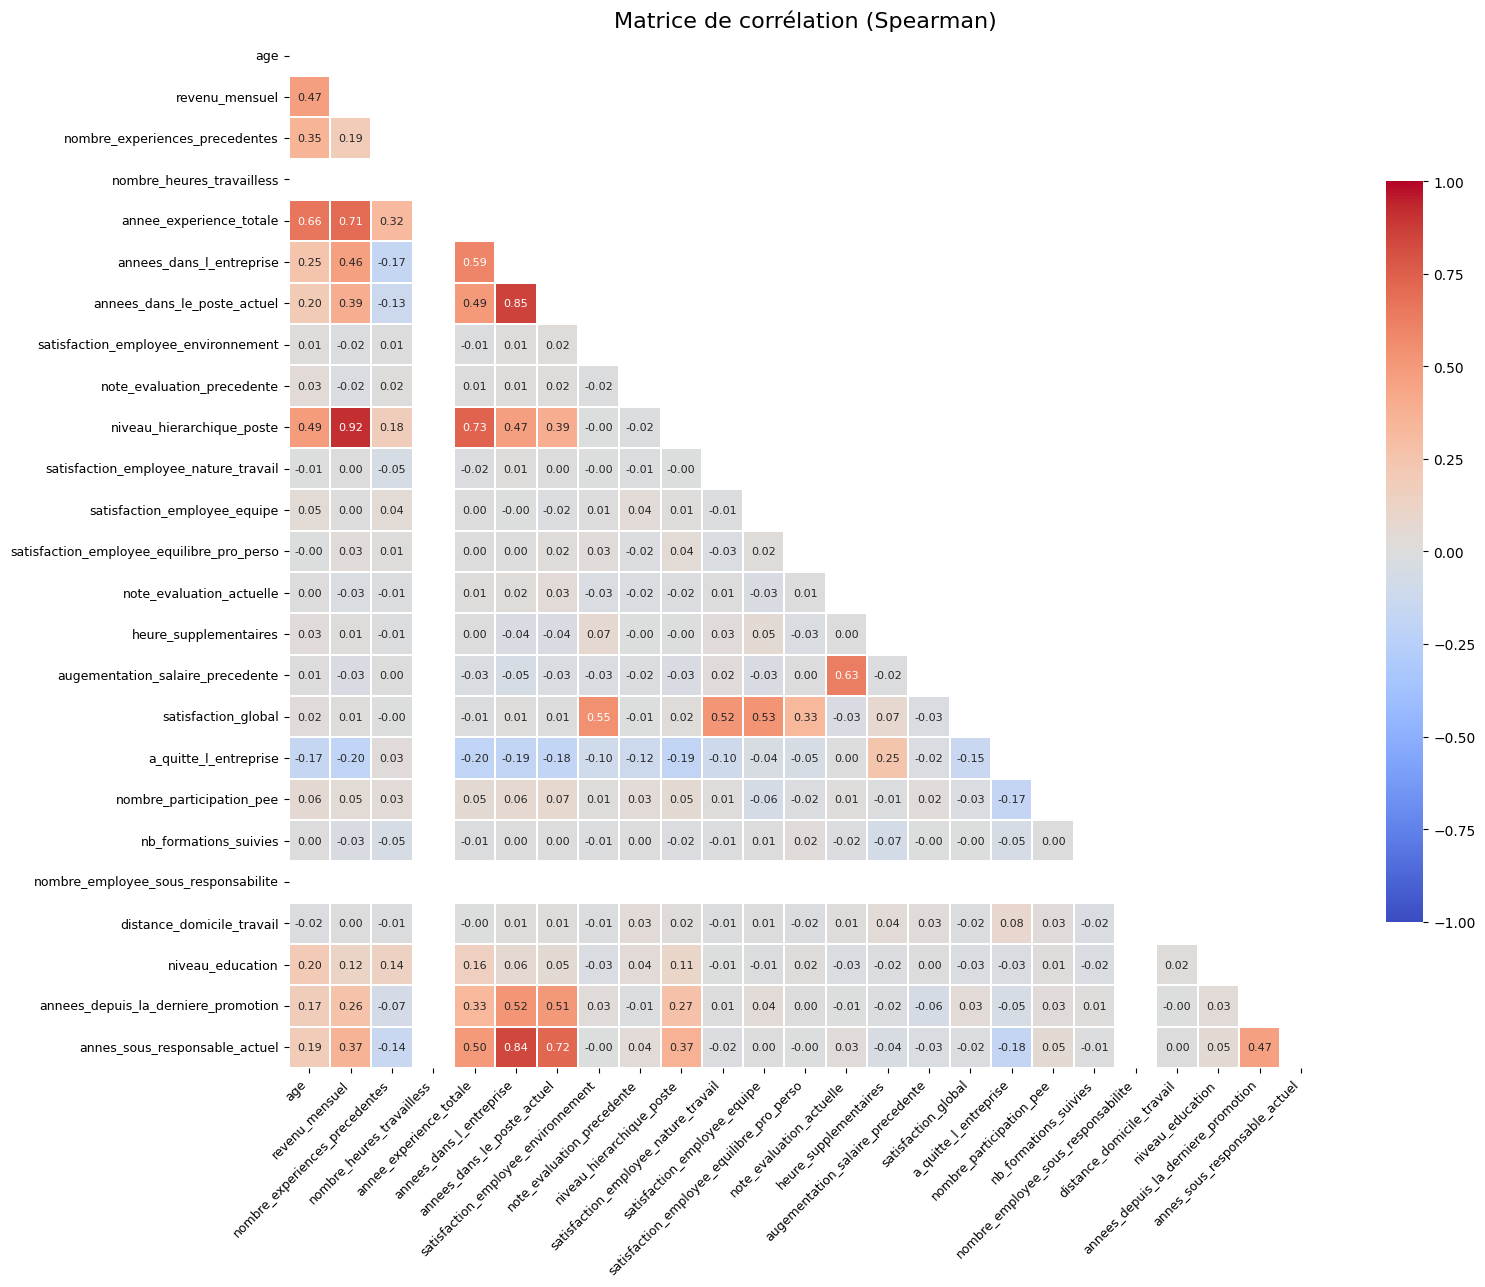

In [13]:
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
corr = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,revenu_mensuel,niveau_hierarchique_poste,0.920429
1,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
2,annees_dans_l_entreprise,annes_sous_responsable_actuel,0.842803
3,annee_experience_totale,niveau_hierarchique_poste,0.734678
4,annees_dans_le_poste_actuel,annes_sous_responsable_actuel,0.724754
5,revenu_mensuel,annee_experience_totale,0.710024


In [18]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,niveau_hierarchique_poste,29.033025
1,annee_experience_totale,9.726838
2,annees_dans_l_entreprise,8.980049
3,annees_dans_le_poste_actuel,6.085786
4,revenu_mensuel,23.931339
5,annes_sous_responsable_actuel,6.316925


# B. Feature engineering

In [377]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

## Tranches d'âge

In [378]:
df.age.describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: age, dtype: float64

In [379]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[17,30,40,50,60],
    labels=["18-30","30-40","40-50","50-60"]
)

In [380]:
df[["age","age_bin"]]

,age,age_bin
0,41,40-50
1,49,40-50
2,37,30-40
3,33,30-40
4,27,18-30
...,...,...
1465,36,30-40
1466,39,30-40
1467,27,18-30
1468,49,40-50


## Tranches de revenu


In [381]:
df.revenu_mensuel.describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: revenu_mensuel, dtype: float64

In [382]:
df["revenu_bin"] = pd.qcut(df["revenu_mensuel"], q=4)

In [383]:
ct = pd.crosstab(df["age_bin"], df["revenu_bin"],normalize='index').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
age_bin,,,,
18-30,0.4663,0.3187,0.1554,0.0596
30-40,0.2084,0.2698,0.3247,0.1971
40-50,0.1335,0.1894,0.2453,0.4317
50-60,0.1189,0.1049,0.1888,0.5874


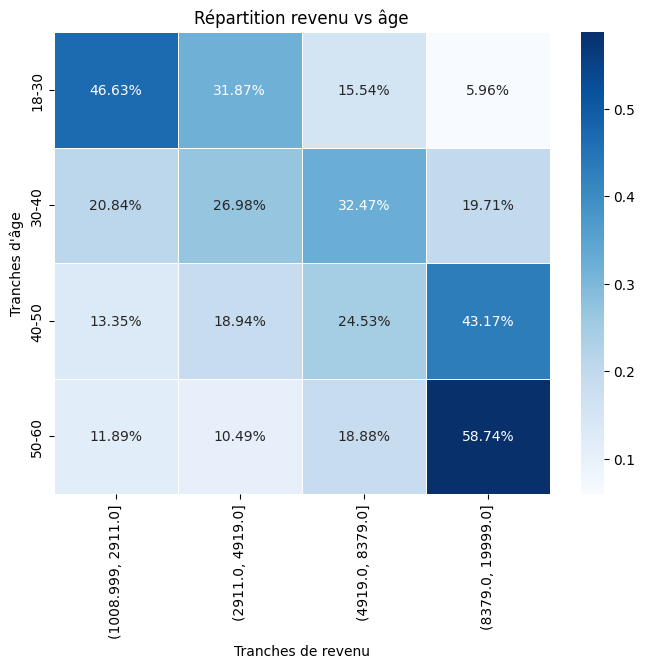

In [384]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs âge")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'âge")

plt.show()

In [385]:
ct = pd.crosstab(df["genre"], df["revenu_bin"],normalize='all')
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
genre,,,,
F,0.091837,0.101361,0.102721,0.104082
M,0.159184,0.147619,0.146939,0.146259


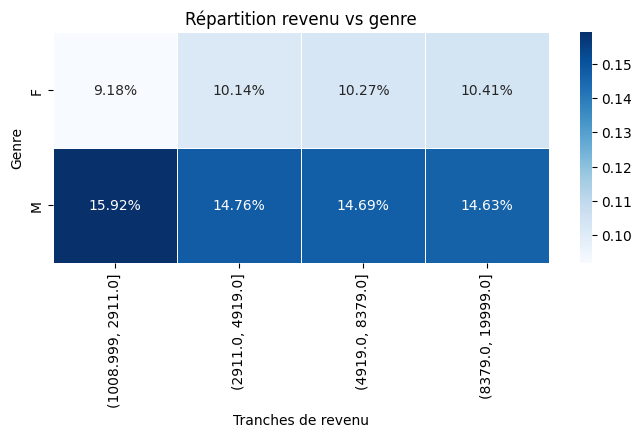

In [386]:
plt.figure(figsize=(8, 3))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs genre")
plt.xlabel("Tranches de revenu")
plt.ylabel("Genre")

plt.show()

## département

In [387]:
ct = pd.crosstab(df["departement"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
departement,,,,
Commercial,0.0435,0.0612,0.1129,0.0857
Consulting,0.1918,0.1796,0.1286,0.1537
Ressources Humaines,0.0156,0.0082,0.0082,0.0109


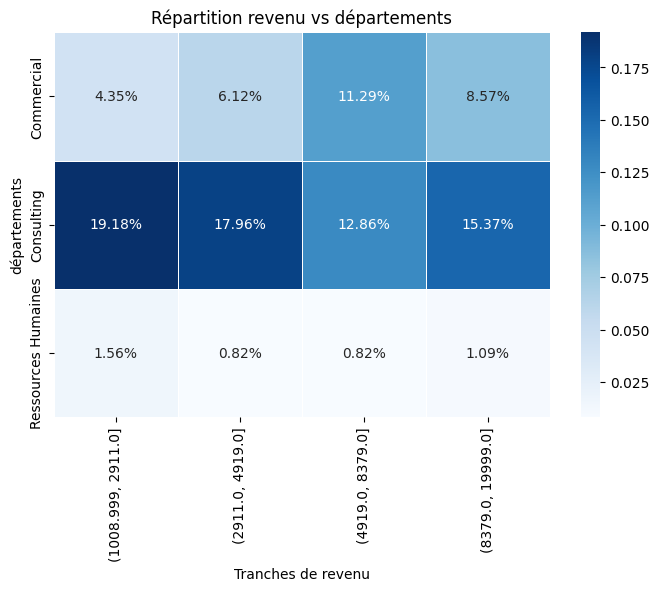

In [388]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs départements")
plt.xlabel("Tranches de revenu")
plt.ylabel("départements")

plt.show()

## Poste

In [389]:
ct = pd.crosstab(df["poste"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
poste,,,,
Assistant de Direction,0.1034,0.0741,0.0204,0.0007
Cadre Commercial,0.0000,0.0497,0.1116,0.0605
Consultant,0.0884,0.0707,0.0170,0.0000
Directeur Technique,0.0000,0.0000,0.0000,0.0544
Manager,0.0000,0.0136,0.0449,0.0306
Représentant Commercial,0.0435,0.0116,0.0014,0.0000
Ressources Humaines,0.0156,0.0082,0.0082,0.0034
Senior Manager,0.0000,0.0000,0.0000,0.0694
Tech Lead,0.0000,0.0211,0.0463,0.0313


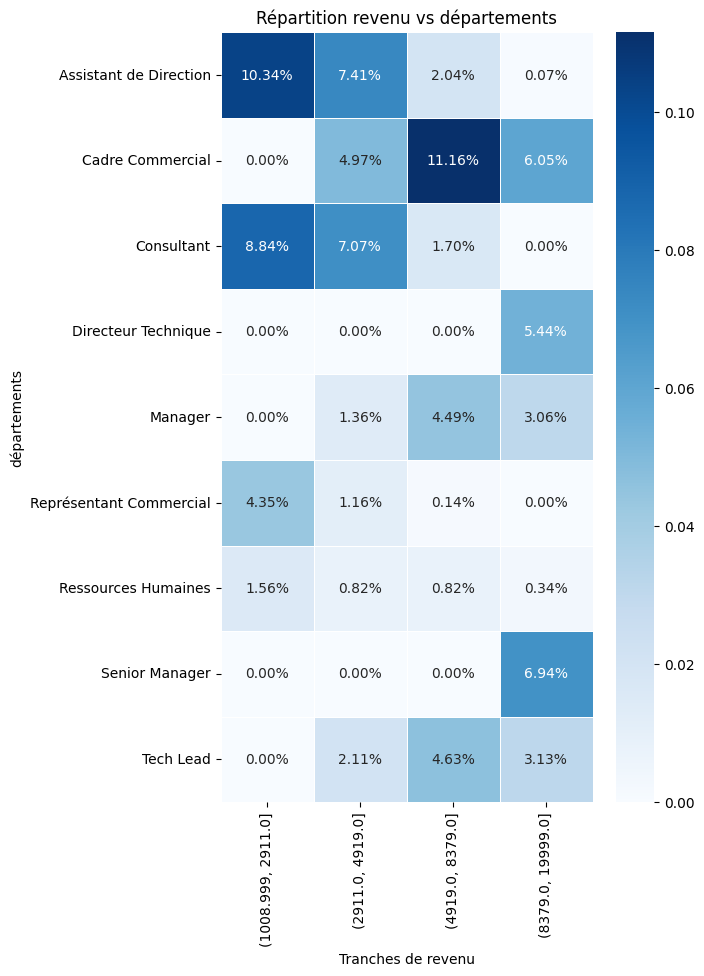

In [390]:
plt.figure(figsize=(6, 10))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs départements")
plt.xlabel("Tranches de revenu")
plt.ylabel("départements")

plt.show()

In [391]:
df["salary_vs_age"] = df["revenu_mensuel"] / (df["age"] + 1)

In [392]:
df["salary_vs_tenure"] = df["revenu_mensuel"] / (df["annees_dans_l_entreprise"] + 1)

In [393]:
df["salary_vs_level"] = df["revenu_mensuel"] / (df["niveau_hierarchique_poste"] + 1)

In [394]:
df["promotion_speed"] = df["annees_depuis_la_derniere_promotion"] / (df["annees_dans_l_entreprise"] + 1)

In [395]:
df["experience_mismatch"] = df["annee_experience_totale"] - df["annees_dans_le_poste_actuel"]

In [396]:
df["is_low_salary_for_job"] = (
    df["revenu_mensuel"] < df.groupby("poste")["revenu_mensuel"].transform("median")
).astype(int)

## Niveau hiérarchique

In [397]:
ct = pd.crosstab(df["niveau_hierarchique_poste"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
niveau_hierarchique_poste,,,,
1,0.2422,0.1245,0.0027,0.0000
2,0.0088,0.1245,0.2102,0.0197
3,0.0000,0.0000,0.0367,0.1116
4,0.0000,0.0000,0.0000,0.0721
5,0.0000,0.0000,0.0000,0.0469


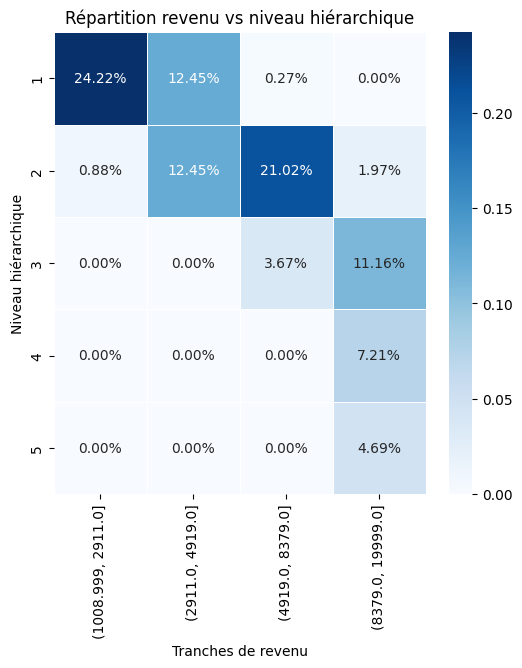

In [398]:
plt.figure(figsize=(6, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs niveau hiérarchique")
plt.xlabel("Tranches de revenu")
plt.ylabel("Niveau hiérarchique")

plt.show()

In [399]:
df["salary_vs_level"] = (
    df["revenu_mensuel"] /
    (df["niveau_hierarchique_poste"] + 1)
)

## Expériences

In [400]:
ct = pd.crosstab(df["nombre_experiences_precedentes"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
nombre_experiences_precedentes,,,,
0,0.0340,0.0463,0.0265,0.0272
1,0.1299,0.0905,0.0782,0.0558
2,0.0136,0.0211,0.0293,0.0354
3,0.0170,0.0231,0.0259,0.0422
4,0.0218,0.0170,0.0286,0.0272
5,0.0068,0.0129,0.0122,0.0109
6,0.0116,0.0082,0.0136,0.0143
7,0.0054,0.0129,0.0143,0.0177
8,0.0061,0.0082,0.0116,0.0075


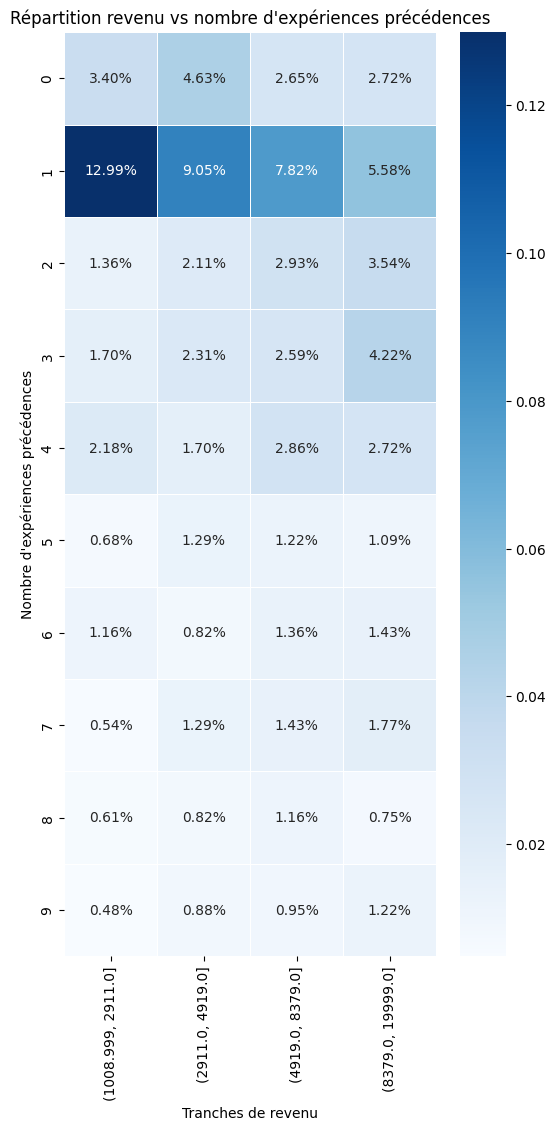

In [401]:
plt.figure(figsize=(6, 12))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs nombre d'expériences précédences")
plt.xlabel("Tranches de revenu")
plt.ylabel("Nombre d'expériences précédences")

plt.show()

## Tranche d'années expérience total

In [402]:
df["xp_total_bin"] = pd.qcut(df["annee_experience_totale"], q=4)

In [403]:
ct = pd.crosstab(df["xp_total_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_total_bin,,,,
"(-0.001, 6.0]",0.1626,0.1068,0.0272,0.0034
"(6.0, 10.0]",0.0619,0.0905,0.1286,0.0469
"(10.0, 15.0]",0.0156,0.0245,0.0578,0.0320
"(15.0, 40.0]",0.0109,0.0272,0.0361,0.1680


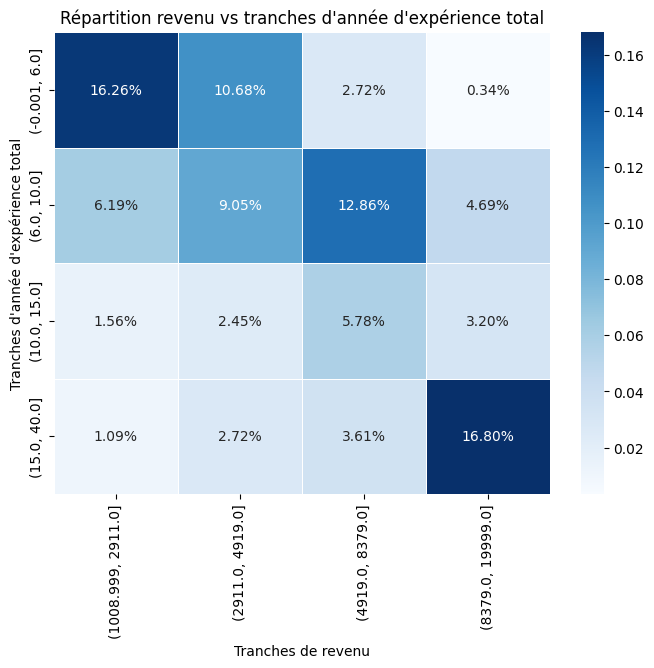

In [404]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs tranches d'année d'expérience total")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'année d'expérience total")

plt.show()

## Tranches d'années dans l'entreprise

In [405]:
df["xp_entr_bin"] = pd.qcut(df["annees_dans_l_entreprise"], q=4)

In [406]:
ct = pd.crosstab(df["xp_entr_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_entr_bin,,,,
"(-0.001, 3.0]",0.1449,0.0837,0.0483,0.0429
"(3.0, 5.0]",0.0565,0.0714,0.0483,0.0320
"(5.0, 9.0]",0.0347,0.0503,0.0850,0.0531
"(9.0, 40.0]",0.0150,0.0435,0.0680,0.1224


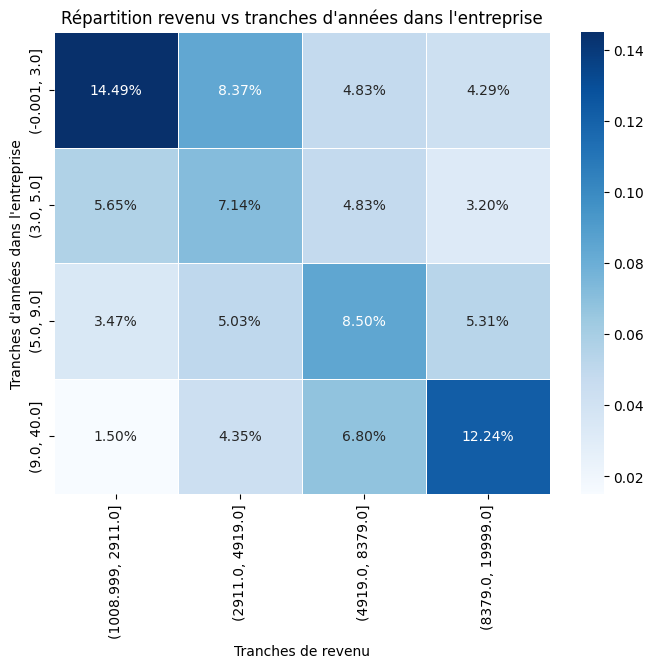

In [407]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs tranches d'années dans l'entreprise")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'années dans l'entreprise")

plt.show()

In [408]:
df["promotion_delay"] = (
    df["annees_dans_l_entreprise"] /
    (df["annees_depuis_la_derniere_promotion"] + 1)
)

## Tranches d'années dans le poste actuel

In [409]:
df["xp_entr_bin"] = pd.qcut(df["annees_dans_le_poste_actuel"], q=4)

In [410]:
ct = pd.crosstab(df["xp_entr_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_entr_bin,,,,
"(-0.001, 2.0]",0.1816,0.1224,0.0850,0.0687
"(2.0, 3.0]",0.0238,0.0299,0.0245,0.0136
"(3.0, 7.0]",0.0361,0.0633,0.0925,0.0796
"(7.0, 18.0]",0.0095,0.0333,0.0476,0.0884


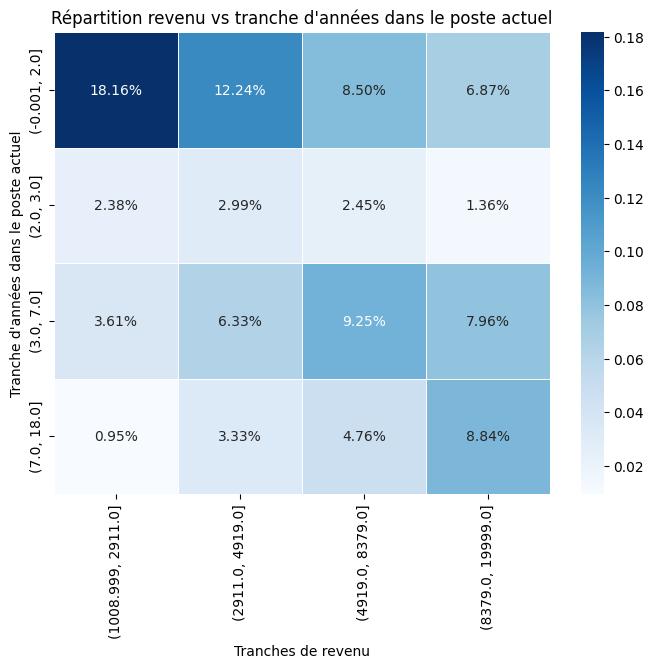

In [411]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs tranche d'années dans le poste actuel")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranche d'années dans le poste actuel")

plt.show()

In [412]:
df["expected_salary"] = df.groupby("niveau_hierarchique_poste")["revenu_mensuel"].transform("median")

df["salary_gap_level"] = df["revenu_mensuel"] - df["expected_salary"]

In [413]:
df["salary_vs_experience"] = df["revenu_mensuel"] / (df["annee_experience_totale"] + 1)

In [414]:
df["fast_promotion"] = (
    df["annees_dans_le_poste_actuel"] < 2
) & (df["niveau_hierarchique_poste"] >= 3)

In [415]:
df["career_stagnation"] = (
    df["annees_depuis_la_derniere_promotion"] > 3
).astype(int)

## Satisfactions

In [416]:
df["satisfaction_bin"] = pd.qcut(df["satisfaction_global"], q=4)

In [417]:
ct = pd.crosstab(df["satisfaction_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
satisfaction_bin,,,,
"(0.999, 2.5]",0.0973,0.1088,0.1014,0.1014
"(2.5, 2.75]",0.0524,0.0497,0.0415,0.0415
"(2.75, 3.0]",0.0422,0.0381,0.0497,0.0503
"(3.0, 4.0]",0.0592,0.0524,0.0571,0.0571


In [418]:
df_eval.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente', 'satisfaction_global'],
      dtype='object')

In [419]:
df["low_sat_flag"] = (df["satisfaction_global"] <= 2.5).astype(int)

## Evaluation

In [420]:
# Evaluation
df["delta_evaluation"] = (
    df["note_evaluation_actuelle"] - df["note_evaluation_precedente"]
)

In [421]:
df["delta_evaluation"].value_counts()

delta_evaluation
 0    757
 1    448
 2    124
-1    124
 3     17
Name: count, dtype: int64

In [422]:
ct = pd.crosstab(df["delta_evaluation"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
delta_evaluation,,,,
-1,0.0204,0.0211,0.0252,0.0177
0,0.1238,0.1401,0.1252,0.1259
1,0.0810,0.0673,0.0762,0.0803
2,0.0238,0.0184,0.0184,0.0238
3,0.0020,0.0020,0.0048,0.0027


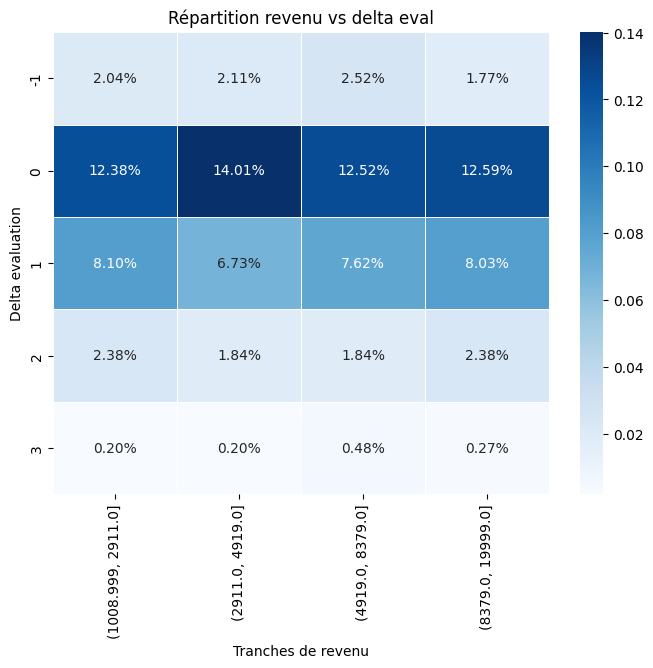

In [423]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs delta eval")
plt.xlabel("Tranches de revenu")
plt.ylabel("Delta evaluation")

plt.show()

In [424]:
ct = pd.crosstab(df["delta_evaluation"], df["satisfaction_bin"],normalize='all').round(4)
ct

satisfaction_bin,"(0.999, 2.5]","(2.5, 2.75]","(2.75, 3.0]","(3.0, 4.0]"
delta_evaluation,,,,
-1,0.0361,0.0170,0.0116,0.0197
0,0.2095,0.0884,0.1007,0.1163
1,0.1204,0.0633,0.0524,0.0687
2,0.0367,0.0143,0.0156,0.0177
3,0.0061,0.0020,0.0000,0.0034


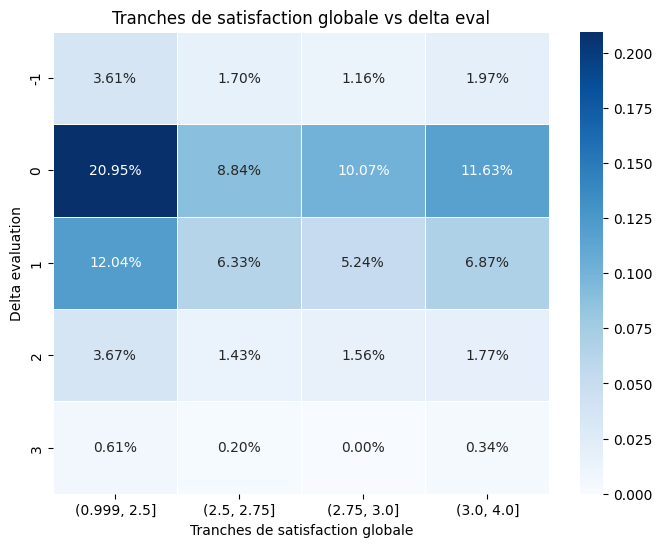

In [425]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Tranches de satisfaction globale vs delta eval")
plt.xlabel("Tranches de satisfaction globale")
plt.ylabel("Delta evaluation")

plt.show()

In [426]:
df["evaluation_declined"] = (df["delta_evaluation"] < 0).astype(int)

## Augmentations

In [427]:
df["bin_raise"] = pd.qcut(df["augementation_salaire_precedente"],q=4)

In [428]:
ct = pd.crosstab(df["bin_raise"], df["delta_evaluation"],normalize='all').round(4)
ct

delta_evaluation,-1,0,1,2,3
bin_raise,,,,,
"(0.109, 0.12]",0.0293,0.1680,0.0694,0.0109,0.0000
"(0.12, 0.14]",0.0184,0.1707,0.0735,0.0163,0.0000
"(0.14, 0.18]",0.0313,0.1333,0.0585,0.0150,0.0000
"(0.18, 0.25]",0.0054,0.0429,0.1034,0.0422,0.0116


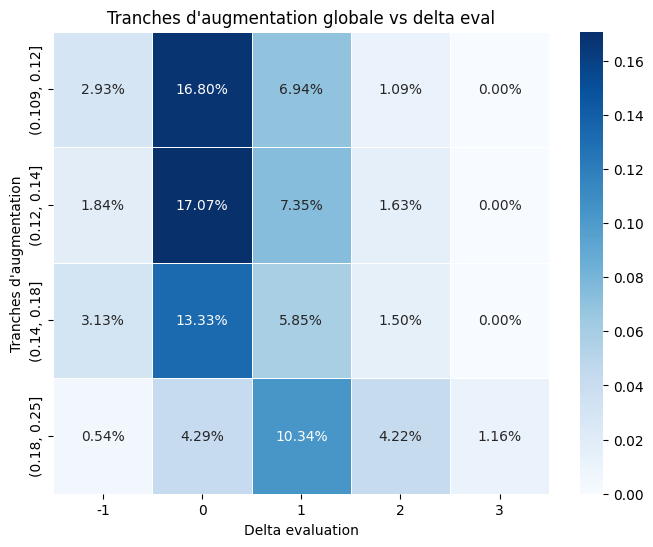

In [429]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches d'augmentation globale vs delta eval")
plt.ylabel("Tranches d'augmentation")
plt.xlabel("Delta evaluation")

plt.show()

In [430]:
ct = pd.crosstab(df["bin_raise"], df["note_evaluation_actuelle"],normalize='all').round(4)
ct

note_evaluation_actuelle,3,4
bin_raise,,
"(0.109, 0.12]",0.2776,0.0000
"(0.12, 0.14]",0.2789,0.0000
"(0.14, 0.18]",0.2381,0.0000
"(0.18, 0.25]",0.0517,0.1537


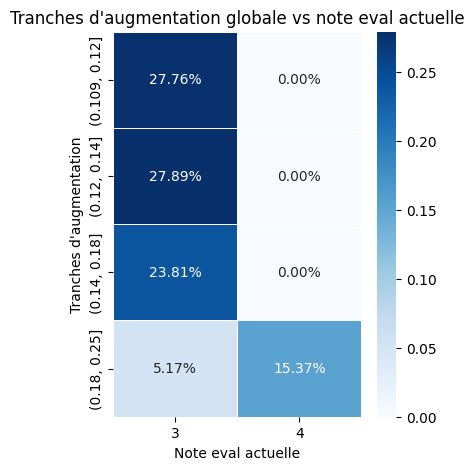

In [431]:
plt.figure(figsize=(4, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches d'augmentation globale vs note eval actuelle")
plt.xlabel("Note eval actuelle")
plt.ylabel("Tranches d'augmentation")

plt.show()

## Distance domicile travail

In [432]:
df["distance_bin"] = pd.qcut(df["distance_domicile_travail"], q=4)

In [433]:
ct = pd.crosstab(df["distance_bin"], df["satisfaction_bin"],normalize='columns').round(4)
ct

satisfaction_bin,"(0.999, 2.5]","(2.5, 2.75]","(2.75, 3.0]","(3.0, 4.0]"
distance_bin,,,,
"(0.999, 2.0]",0.2762,0.2684,0.3132,0.2922
"(2.0, 7.0]",0.2246,0.2978,0.2340,0.2349
"(7.0, 14.0]",0.2446,0.2132,0.2415,0.2139
"(14.0, 29.0]",0.2546,0.2206,0.2113,0.2590


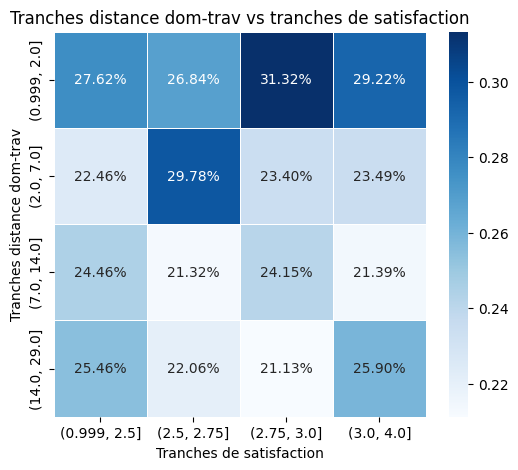

In [434]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches distance dom-trav vs tranches de satisfaction")
plt.xlabel("Tranches de satisfaction")
plt.ylabel("Tranches distance dom-trav")

plt.show()

## Log des valeurs extrêmes

In [435]:
outliers, ratio = of.detect_outliers_iqr(df.select_dtypes(include="number"))

ratio.sort_values(ascending=False)

career_stagnation                            21.836735
nb_formations_suivies                        16.190476
a_quitte_l_entreprise                        16.122449
note_evaluation_actuelle                     15.374150
salary_vs_tenure                             10.272109
evaluation_declined                           8.435374
experience_mismatch                           7.823129
revenu_mensuel                                7.755102
annees_depuis_la_derniere_promotion           7.278912
annees_dans_l_entreprise                      7.074830
salary_gap_level                              6.802721
promotion_delay                               6.598639
nombre_participation_pee                      5.782313
annee_experience_totale                       4.285714
nombre_experiences_precedentes                3.537415
salary_vs_experience                          2.925170
salary_vs_age                                 2.857143
satisfaction_global                           2.448980
annees_dan

In [436]:
df["log_revenu"] = np.log1p(df["revenu_mensuel"])
df["log_dist_dom_trav"] = np.log1p(df["distance_domicile_travail"])
df["log_annees_depuis_last_promo"] = np.log1p(df["annees_depuis_la_derniere_promotion"])
df["log_annees_in_entr"] = np.log1p(df["annees_dans_l_entreprise"])
df["log_annee_experience_totale"] = np.log1p(df["annee_experience_totale"])
df["log_annees_poste_actuel"] = np.log1p(df["annees_dans_le_poste_actuel"])

# Last cleaning

In [437]:
df = df.loc[:, df.nunique() > 1]

## Nouvelles features après analyse des faux négatifs

In [438]:
df["high_salary_low_sat"] = (
    (df["revenu_mensuel"] > df["revenu_mensuel"].median()) &
    (df["satisfaction_global"] < 3)
).astype(int)

In [439]:
df["stagnation_ratio"] = (
    df["annees_depuis_la_derniere_promotion"] /
    (df["annees_dans_l_entreprise"] + 1)
)

In [440]:
df["salary_satisfaction_gap"] = (
    df["revenu_mensuel"] * (5 - df["satisfaction_global"])
)

In [441]:
df["senior_in_role"] = (
    df["annees_dans_le_poste_actuel"] > 5
).astype(int)

In [442]:
df["hidden_risk"] = (
    (df["revenu_mensuel"] > df["revenu_mensuel"].median()) &
    (df["annees_dans_le_poste_actuel"] > 4) &
    (df["satisfaction_global"] > 2.5)
).astype(int)

# Export 

In [443]:
df.to_csv("/home/maxime/projects/technova-attrition/data/interim/data.csv")

In [444]:
df.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'annee_experience_totale', 'annees_dans_l_entreprise',
       'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement',
       'note_evaluation_precedente', 'niveau_hierarchique_poste',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente', 'satisfaction_global',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'code_sondage', 'distance_domicile_travail',
       'niveau_education', 'domaine_etude', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'age_bin', 'revenu_bin', 'salary_vs_age', 'salary_vs_tenure',
       'salary_vs_level', 'pro